In [6]:
# If needed, install dependencies in the active notebook environment

# %pip install torch torchvision scikit-learn matplotlib pillow gradio opencv-python



import os

import random

from pathlib import Path

from collections import Counter



import cv2

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image



import torch

import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms



from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix



SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [7]:
# Paths and training configuration (CPU friendly)

PROJECT_ROOT = Path.cwd()

CASIA_ROOT = PROJECT_ROOT / "public_test_images" / "public" / "archive" / "CASIA2"

PUBLIC_IMAGES_DIR = PROJECT_ROOT / "public_test_images" / "public" / "images"



AUTH_DIR = CASIA_ROOT / "Au"

TAMPER_DIR = CASIA_ROOT / "Tp"

GT_DIR = CASIA_ROOT / "CASIA 2 Groundtruth"  # optional masks, not mandatory for training



IMG_SIZE = 224

BATCH_SIZE = 12

NUM_WORKERS = 0

EPOCHS = 2

LR = 1e-4



# Keep these moderate for i5 CPU training speed.

MAX_AUTH_SAMPLES = 800

MAX_TAMPER_SAMPLES = 800



MODEL_PATH = PROJECT_ROOT / "casia_resnet18_forgery.pth"



for p in [AUTH_DIR, TAMPER_DIR]:

    print(p, "exists:", p.exists())

e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\IMLDS Elective\CA3\Implementation\public_test_images\public\archive\CASIA2\Au exists: True
e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\IMLDS Elective\CA3\Implementation\public_test_images\public\archive\CASIA2\Tp exists: True


In [8]:
def list_images(root: Path):

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    if not root.exists():

        return []

    return [p for p in root.rglob("*") if p.suffix.lower() in exts]



auth_paths = list_images(AUTH_DIR)

tamper_paths = list_images(TAMPER_DIR)



print("Authentic images:", len(auth_paths))

print("Tampered images:", len(tamper_paths))



if MAX_AUTH_SAMPLES is not None:

    auth_paths = random.sample(auth_paths, k=min(MAX_AUTH_SAMPLES, len(auth_paths)))

if MAX_TAMPER_SAMPLES is not None:

    tamper_paths = random.sample(tamper_paths, k=min(MAX_TAMPER_SAMPLES, len(tamper_paths)))



all_paths = auth_paths + tamper_paths

all_labels = [0] * len(auth_paths) + [1] * len(tamper_paths)



print("Using samples:", Counter(all_labels), "(0=authentic, 1=tampered)")

Authentic images: 7491
Tampered images: 5123
Using samples: Counter({0: 800, 1: 800}) (0=authentic, 1=tampered)


In [9]:
class CasiaBinaryDataset(Dataset):

    def __init__(self, paths, labels, transform=None):

        self.paths = paths

        self.labels = labels

        self.transform = transform



    def __len__(self):

        return len(self.paths)



    def __getitem__(self, idx):

        path = self.paths[idx]

        label = self.labels[idx]

        img = Image.open(path).convert("RGB")

        if self.transform is not None:

            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long), str(path)



train_paths, val_paths, train_labels, val_labels = train_test_split(

    all_paths,

    all_labels,

    test_size=0.2,

    random_state=SEED,

    stratify=all_labels,

)



train_tfms = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

])



val_tfms = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

])



train_ds = CasiaBinaryDataset(train_paths, train_labels, transform=train_tfms)

val_ds = CasiaBinaryDataset(val_paths, val_labels, transform=val_tfms)



train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)



print("Train size:", len(train_ds), "Val size:", len(val_ds))

Train size: 1280 Val size: 320


In [10]:
# Model setup: pretrained ResNet18 (lightweight) for binary classification

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)



# Freeze most layers for faster CPU fine-tuning

for p in model.parameters():

    p.requires_grad = False

for p in model.layer4.parameters():

    p.requires_grad = True



in_features = model.fc.in_features

model.fc = nn.Linear(in_features, 2)

model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)



def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for x, y, _ in loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()



        running_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)

        correct += (preds == y).sum().item()

        total += y.size(0)



    return running_loss / max(total, 1), correct / max(total, 1)



@torch.no_grad()

def validate(model, loader, criterion, device):

    model.eval()

    running_loss, correct, total = 0.0, 0, 0

    all_y, all_p = [], []



    for x, y, _ in loader:

        x, y = x.to(device), y.to(device)

        logits = model(x)

        loss = criterion(logits, y)



        running_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)

        correct += (preds == y).sum().item()

        total += y.size(0)



        all_y.extend(y.cpu().numpy().tolist())

        all_p.extend(preds.cpu().numpy().tolist())



    return running_loss / max(total, 1), correct / max(total, 1), all_y, all_p



best_val_acc = 0.0

history = []



for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    va_loss, va_acc, _, _ = validate(model, val_loader, criterion, device)

    history.append((tr_loss, tr_acc, va_loss, va_acc))



    print(f"Epoch {epoch}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")



    if va_acc > best_val_acc:

        best_val_acc = va_acc

        torch.save(model.state_dict(), MODEL_PATH)



print("Best val acc:", round(best_val_acc, 4))

print("Saved best model to:", MODEL_PATH)



if MODEL_PATH.exists():

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))



_, _, y_true, y_pred = validate(model, val_loader, criterion, device)

print("\nClassification report:\n")

print(classification_report(y_true, y_pred, target_names=["Authentic", "Tampered"], digits=4))

print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

Epoch 1/2 | train_loss=0.6692 train_acc=0.6156 | val_loss=0.7028 val_acc=0.6406
Epoch 2/2 | train_loss=0.4449 train_acc=0.8023 | val_loss=0.7204 val_acc=0.6469
Best val acc: 0.6469
Saved best model to: e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\IMLDS Elective\CA3\Implementation\casia_resnet18_forgery.pth

Classification report:

              precision    recall  f1-score   support

   Authentic     0.6643    0.5938    0.6271       160
    Tampered     0.6328    0.7000    0.6647       160

    accuracy                         0.6469       320
   macro avg     0.6486    0.6469    0.6459       320
weighted avg     0.6486    0.6469    0.6459       320

Confusion matrix:
 [[ 95  65]
 [ 48 112]]


In [13]:
# Proper checkpoint save + reusable inference utilities

CLASS_NAMES = ["Authentic", "Tampered"]

CHECKPOINT_PATH = PROJECT_ROOT / "casia_resnet18_checkpoint.pt"



checkpoint = {

    "model_name": "resnet18",

    "num_classes": 2,

    "class_names": CLASS_NAMES,

    "img_size": IMG_SIZE,

    "mean": [0.485, 0.456, 0.406],

    "std": [0.229, 0.224, 0.225],

    "best_val_acc": float(best_val_acc),

    "state_dict": model.state_dict(),

}

torch.save(checkpoint, CHECKPOINT_PATH)

print("Checkpoint saved:", CHECKPOINT_PATH)



def load_model_from_checkpoint(checkpoint_path, device):

    ckpt = torch.load(checkpoint_path, map_location=device)

    m = models.resnet18(weights=None)

    in_features = m.fc.in_features

    m.fc = nn.Linear(in_features, ckpt.get("num_classes", 2))

    m.load_state_dict(ckpt["state_dict"])

    m = m.to(device)

    m.eval()

    return m, ckpt



def preprocess_for_inference(pil_image, img_size, mean, std):

    tfm = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.ToTensor(),

        transforms.Normalize(mean=mean, std=std),

    ])

    return tfm(pil_image).unsqueeze(0)



@torch.no_grad()

def predict_image(model, ckpt, image_path, device):

    pil_img = Image.open(image_path).convert("RGB")

    x = preprocess_for_inference(

        pil_img,

        img_size=ckpt["img_size"],

        mean=ckpt["mean"],

        std=ckpt["std"],

    ).to(device)



    logits = model(x)

    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))

    class_names = ckpt.get("class_names", CLASS_NAMES)

    return {

        "image_path": str(image_path),

        "pred_idx": pred_idx,

        "pred_label": class_names[pred_idx],

        "confidence": float(probs[pred_idx]),

        "prob_authentic": float(probs[0]),

        "prob_tampered": float(probs[1]),

    }



def run_batch_inference(image_dir, out_csv_path, max_images=50):

    import pandas as pd

    model_inf, ckpt = load_model_from_checkpoint(CHECKPOINT_PATH, device)

    paths = list_images(Path(image_dir))[:max_images]

    rows = [predict_image(model_inf, ckpt, p, device) for p in paths]

    df = pd.DataFrame(rows)

    df.to_csv(out_csv_path, index=False)

    return df



# Quick demo inference on one validation image

model_inf, ckpt = load_model_from_checkpoint(CHECKPOINT_PATH, device)

demo_pred = predict_image(model_inf, ckpt, val_paths[0], device)

print("Demo inference:", demo_pred)



# Optional: batch inference on public images folder and save CSV

BATCH_CSV = PROJECT_ROOT / "public_images_predictions.csv"

df_preds = run_batch_inference(PUBLIC_IMAGES_DIR, BATCH_CSV, max_images=100)

print("Batch inference CSV saved:", BATCH_CSV)

display(df_preds.head())

Checkpoint saved: e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\IMLDS Elective\CA3\Implementation\casia_resnet18_checkpoint.pt
Demo inference: {'image_path': 'e:\\Sharvayu data\\Malware\\Symbiosis Nagpur SIT\\6th SEM\\IMLDS Elective\\CA3\\Implementation\\public_test_images\\public\\archive\\CASIA2\\Tp\\Tp_S_CNN_S_N_ind20001_ind20001_02261.tif', 'pred_idx': 0, 'pred_label': 'Authentic', 'confidence': 0.7750029563903809, 'prob_authentic': 0.7750029563903809, 'prob_tampered': 0.22499705851078033}
Batch inference CSV saved: e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\IMLDS Elective\CA3\Implementation\public_images_predictions.csv


,image_path,pred_idx,pred_label,confidence,prob_authentic,prob_tampered
0,e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\...,0,Authentic,0.611054,0.611054,0.388945
1,e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\...,0,Authentic,0.975367,0.975367,0.024633
2,e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\...,1,Tampered,0.934542,0.065458,0.934542
3,e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\...,0,Authentic,0.941149,0.941149,0.058851
4,e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\...,1,Tampered,0.899712,0.100288,0.899712


Prediction: Authentic (0.7750)


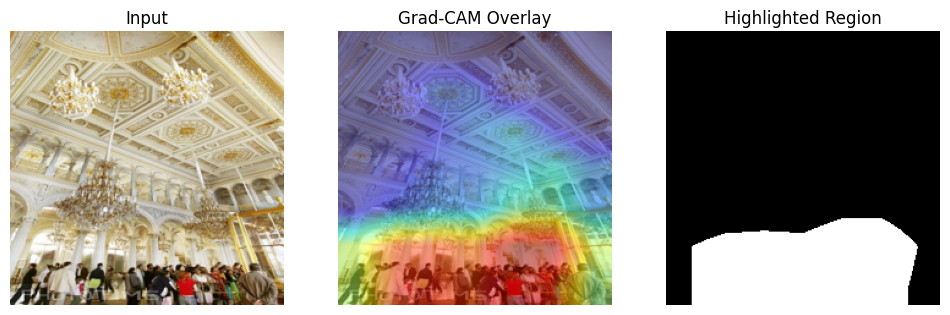

In [11]:
# Grad-CAM for explainable forgery localization

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)

IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)



class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model

        self.target_layer = target_layer

        self.activations = None

        self.gradients = None



        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)

        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)



    def _forward_hook(self, module, inp, out):

        self.activations = out.detach()



    def _backward_hook(self, module, grad_input, grad_output):

        self.gradients = grad_output[0].detach()



    def __call__(self, input_tensor, class_idx=None):

        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)



        if class_idx is None:

            class_idx = int(torch.argmax(logits, dim=1).item())



        score = logits[:, class_idx]

        score.backward(retain_graph=True)



        grads = self.gradients[0]      # [C,H,W]

        acts = self.activations[0]     # [C,H,W]

        weights = grads.mean(dim=(1, 2), keepdim=True)

        cam = (weights * acts).sum(dim=0)

        cam = torch.relu(cam)

        cam = cam - cam.min()

        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), logits.detach()



    def close(self):

        self.fwd_handle.remove()

        self.bwd_handle.remove()



def preprocess_pil(pil_img):

    tfm = transforms.Compose([

        transforms.Resize((IMG_SIZE, IMG_SIZE)),

        transforms.ToTensor(),

        transforms.Normalize(mean=IMAGENET_MEAN.tolist(), std=IMAGENET_STD.tolist())

    ])

    return tfm(pil_img).unsqueeze(0)



def denorm_to_uint8(img_tensor):

    x = img_tensor.detach().cpu().permute(1, 2, 0).numpy()

    x = (x * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

    x = (x * 255).astype(np.uint8)

    return x



def overlay_cam(rgb_img_uint8, cam):

    h, w = rgb_img_uint8.shape[:2]

    cam_resized = cv2.resize(cam, (w, h))

    heat = np.uint8(255 * cam_resized)

    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(rgb_img_uint8, 0.55, heat, 0.45, 0)

    return overlay, cam_resized



def predict_and_explain(image_path):

    pil_img = Image.open(image_path).convert("RGB")

    inp = preprocess_pil(pil_img).to(device)

    model.eval()



    gradcam = GradCAM(model, model.layer4[-1].conv2)

    cam, logits = gradcam(inp)

    gradcam.close()



    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred = int(np.argmax(probs))

    label = "Tampered" if pred == 1 else "Authentic"

    conf = float(probs[pred])



    original = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))

    overlay, cam_map = overlay_cam(original, cam)

    mask = (cam_map > 0.60).astype(np.uint8) * 255



    return {

        "label": label,

        "confidence": conf,

        "original": original,

        "overlay": overlay,

        "forgery_mask": mask

    }



# Demo on one validation image

demo_path = val_paths[0] if len(val_paths) > 0 else None

if demo_path is not None:

    out = predict_and_explain(demo_path)

    print(f"Prediction: {out['label']} ({out['confidence']:.4f})")



    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)

    plt.imshow(out["original"])

    plt.title("Input")

    plt.axis("off")



    plt.subplot(1, 3, 2)

    plt.imshow(out["overlay"])

    plt.title("Grad-CAM Overlay")

    plt.axis("off")



    plt.subplot(1, 3, 3)

    plt.imshow(out["forgery_mask"], cmap="gray")

    plt.title("Highlighted Region")

    plt.axis("off")

    plt.show()

In [15]:
# Simple frontend UI using Gradio + Ollama summary

import json

import urllib.request

import urllib.error

import socket

import gradio as gr



OLLAMA_URL = "http://127.0.0.1:11434/api/generate"

OLLAMA_TAGS_URL = "http://127.0.0.1:11434/api/tags"

OLLAMA_MODEL = "llama3.2:3b"  # preferred model



def resolve_ollama_model(preferred_model):

    try:

        with urllib.request.urlopen(OLLAMA_TAGS_URL, timeout=10) as resp:

            data = json.loads(resp.read().decode("utf-8"))

            model_names = [m.get("name", "") for m in data.get("models", []) if m.get("name")]

            if preferred_model in model_names:

                return preferred_model

            if model_names:

                print(f"Preferred model '{preferred_model}' not found. Using '{model_names[0]}'")

                return model_names[0]

    except Exception:

        pass

    return preferred_model



def get_free_port(start=7860, end=7870):

    for port in range(start, end + 1):

        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:

            s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)

            if s.connect_ex(("127.0.0.1", port)) != 0:

                return port

    return 7860



ACTIVE_OLLAMA_MODEL = resolve_ollama_model(OLLAMA_MODEL)

print("Ollama model in use:", ACTIVE_OLLAMA_MODEL)



def summarize_with_ollama(label, confidence, tamper_ratio):

    prompt = (

        "You are a concise forensic assistant. "

        "Write a short 1-2 sentence summary for this forgery detection output. "

        f"Prediction: {label}. Confidence: {confidence:.4f}. "

        f"Highlighted suspicious area ratio: {tamper_ratio:.2%}. "

        "Keep it simple for a non-technical user."

    )



    payload = {

        "model": ACTIVE_OLLAMA_MODEL,

        "prompt": prompt,

        "stream": False

    }



    req = urllib.request.Request(

        OLLAMA_URL,

        data=json.dumps(payload).encode("utf-8"),

        headers={"Content-Type": "application/json"},

        method="POST"

    )



    try:

        with urllib.request.urlopen(req, timeout=20) as resp:

            data = json.loads(resp.read().decode("utf-8"))

            text = data.get("response", "").strip()

            if text:

                return text

            return "Summary unavailable from Ollama response."

    except urllib.error.URLError:

        return "Ollama not reachable on 127.0.0.1:11434. Start Ollama to enable AI summary."

    except Exception as e:

        return f"Ollama summary error: {e}"



def ui_predict(pil_image):

    if pil_image is None:

        return None, None, "No image uploaded.", "No summary."



    temp_path = PROJECT_ROOT / "_temp_upload_for_xai.jpg"

    pil_image.convert("RGB").save(temp_path)

    out = predict_and_explain(temp_path)



    tamper_ratio = float((out["forgery_mask"] > 0).mean())

    result_text = f"Prediction: {out['label']} | Confidence: {out['confidence']:.4f} | Highlighted area: {tamper_ratio:.2%}"

    ai_summary = summarize_with_ollama(out["label"], out["confidence"], tamper_ratio)



    return out["overlay"], out["forgery_mask"], result_text, ai_summary



demo = gr.Interface(

    fn=ui_predict,

    inputs=gr.Image(type="pil", label="Upload Image"),

    outputs=[

        gr.Image(type="numpy", label="Grad-CAM Output"),

        gr.Image(type="numpy", label="Highlighted Forgery Region"),

        gr.Textbox(label="Detection Result"),

        gr.Textbox(label="AI Summary (Ollama)")

    ],

    title="CASIA Forgery Detection (ResNet18 + Grad-CAM)",

    description="Upload an image and get forgery classification, highlighted regions, and a short AI summary from local Ollama."

)



LAUNCH_PORT = get_free_port(7860, 7870)

print("Launching Gradio on port:", LAUNCH_PORT)

demo.launch(share=False, server_name="127.0.0.1", server_port=LAUNCH_PORT)

Preferred model 'llama3.2:3b' not found. Using 'gemma3:4b'
Ollama model in use: gemma3:4b
Launching Gradio on port: 7861
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
